# MARLIM COM O GERADOR GLOBAL

Reproduz três regiões do bloco de Marlim usando a classe **`SyntheticGenerator`
(`../Synthetic/index.py`) sem alterar uma linha dela**. Cada região é só um dicionário de
opções da classe mais quatro números de domínio (`MarlimRegion`).

| região | banda z | σ | pico do espectro | coerência | anotação |
|---|---|---|---|---|---|
| `calmo`   | 250–620   | 0.167 | 0.165 c/vox | 0.98 | 0.0070 |
| `falhado` | 620–1200  | 0.159 | 0.048 c/vox | 0.92 | 0.0157 |
| `morto`   | 1200–1500 | 0.021 | 0.040 c/vox | 0.65 | 0.0043 |

**Como se mede a distância até o alvo.** Cada seção 128×128 vira um vetor de **40
features** (espectros, coerência e mergulho do tensor de estrutura, amplitude,
continuidade lateral). A mesma função roda no recorte real e no tile sintético, e o erro
de cada feature é medido **em desvios robustos do próprio bloco naquela banda** — então
`|desvio| < 1` quer dizer *dentro da variação natural da região*.

**Resultado** (96 tiles 3D por região): score `calmo` 0.169, `falhado` 0.292, `morto`
1.369; desvio médio 0.21 / 0.28 / 0.60 σ. O resíduo do `morto` é quase todo coerência —
ver a seção de limites no fim.

A busca que produziu o `CONFIG` vive no **`Calibrate.ipynb`** (é código de uso único e
custa horas). Aqui só se gera, valida e compara.

Fluxo: `Generator2.ipynb` → `../Dataset/dataset_marlim_opt_2/Format.ipynb` → treino
(`../Model/Analysis.ipynb`) → `Predict.ipynb` → `Analysis.ipynb`.

In [ ]:
import os, re, sys, json, shutil
from math import floor
from pathlib import Path
import multiprocessing as mp
from concurrent.futures import ProcessPoolExecutor

import numpy as np
import matplotlib.pyplot as plt
import scipy.ndimage as ndi
from PIL import Image
from tqdm import tqdm

np.random.seed(42)
sys.path.append('../Synthetic')
from index import SyntheticGenerator 

PATCH_IDS  = ['1200', '1300', '1400', '2600']
CACHE_DIR  = 'files/cache'
MARLIM_DIR = '../Dataset/marlim'
DATASET    = 'dataset_marlim_opt_2'
OUT_DIR    = f'../Dataset/{DATASET}'

SHAPE, CLIP = (128, 128, 128), 0.45   # tile e saturação simétrica (o slab real satura)
PER_REGION  = 220                     # 3 × 220 = 660 tiles
SEED0       = 20260816                # semente = SEED0 + 1000*região + tile
PILOT_N     = 96                      # tiles 3D por região usados na validação
NJOBS       = min(20, os.cpu_count())
GENERATE    = True                    # False = só valida, não grava o dataset

## 1. O bloco real
As seções centrais dos patches 1200/1300/1400/2600 (1601 × 2240, já em [0,1]) são a única
fonte de verdade: delas saem tanto o alvo quanto a régua. A coluna vertical do slab tem
água até z≈250, pacote raso bem estratificado até 620, o intervalo produtivo 620–1200
(onde o especialista anotou 2× mais falha) e zona morta acima de 1200. Cerca de 1.4% do
slab está grudado em 0 e outros 1.4% em 1 — ele já foi normalizado pelo próprio p01/p99,
e é por isso que o sintético também satura, em ±`CLIP`.

In [ ]:
# SEÇÃO CENTRAL (1601, 2240) DO PATCH, EM [0,1] — SÓ REMONTA DOS patch_*.dat SE O CACHE NÃO EXISTIR
def marlimSection(pid):
    cache = f'{CACHE_DIR}/real_center_{pid}.npy'
    if os.path.exists(cache):
        return np.load(cache)

    meta = json.load(open('files/patch_metadata.json'))
    ps, ov = meta['patch_size'], meta['overlap_voxels']
    shape  = tuple(meta['original_shape'])
    stride = ps - 2*ov
    last   = [floor(n/stride) for n in shape]
    vol    = np.zeros(shape, np.float32)

    for fname in tqdm(sorted(os.listdir(f'{MARLIM_DIR}/patch_{pid}')), desc=f'patch_{pid}'):
        m = re.match(r'patch_d(\d+)_h(\d+)_w(\d+)\.dat', fname)
        if not m:
            continue

        origin = [max(0, s - stride) if i == l else i*stride
                  for i, l, s in zip(map(int, m.groups()), last, shape)]
        core = np.fromfile(f'{MARLIM_DIR}/patch_{pid}/{fname}', np.float32).reshape((ps,)*3)
        core = core[ov:ps-ov, ov:ps-ov, ov:ps-ov]
        n = [min(core.shape[k], shape[k] - origin[k]) for k in range(3)]
        d, h, w = origin
        vol[d:d+n[0], h:h+n[1], w:w+n[2]] = core[:n[0], :n[1], :n[2]]

    os.makedirs(CACHE_DIR, exist_ok=True)
    sec = vol[shape[0]//2].copy()
    np.save(cache, sec)
    return sec


SECTIONS = {p: marlimSection(p) for p in PATCH_IDS}
INTERPRETADO = {p: np.array(Image.open(f'files/patches/{p}/{p}_interpretado.png').convert('L')) > 128 for p in PATCH_IDS}

REGIONS = {
    'calmo': {
        'zband': (250,  620),
        'reals': [('1200',  300,  800), ('1300',  400, 1500), ('2600',  330, 1300)]
    },
    'falhado': {
        'zband': (620, 1200),
        'reals': [('1200',  700, 1300), ('1300',  950, 1400), ('2600', 1000, 1800)]
    },
    'morto': {
        'zband': (1200, 1500),
        'reals': [('1200', 1300,  800), ('1400', 1300,  600), ('2600', 1200, 1300)]
    },
}

for name, cfg in REGIONS.items():
    zlo, zhi = cfg['zband']
    s = np.concatenate([SECTIONS[p][zlo:zhi].ravel() for p in PATCH_IDS])
    a = np.mean([INTERPRETADO[p][zlo:zhi].mean() for p in PATCH_IDS])
    print(f'{name:9s} z {zlo:4d}-{zhi:4d} σ={s.std():.3f}  μ={s.mean():.3f} saturado={(np.minimum(s, 1-s) == 0).mean()*100:4.1f}%  anotação={a:.4f}')

calmo     z  250- 620   σ=0.181  μ=0.502  saturado= 4.5%  anotação=0.0075
falhado   z  620-1200   σ=0.175  μ=0.503  saturado= 4.4%  anotação=0.0149
morto     z 1200-1500   σ=0.038  μ=0.503  saturado= 0.0%  anotação=0.0043


## 2. A régua
As 40 features abaixo descrevem uma seção 128×128 em [0,1], e o alvo de cada região são
os **quantis p10/p50/p90** delas sobre os recortes reais da banda. `TARGET` também guarda
a geometria das falhas do especialista (fração de máscara, seções vazias, traços por
seção, mergulho e comprimento).

| feature | o que descreve |
|---|---|
| `logstd` | contraste (é o que o ganho resolve) |
| `Pz0..Pz7`, `logpkz` | forma e pico do espectro vertical (assinatura da wavelet) |
| `Px0..Px5` | espectro lateral (comprimento de onda das dobras) |
| `cohw`, `coh25..75` | coerência do tensor de estrutura (continuidade do refletor) |
| `dip10..dip90` | mergulho aparente com sinal, ponderado pela energia (0° = deitado) |
| `p01..p99`, `kurt` | distribuição de amplitude, inclusive a saturação |
| `lag1..lag16` | correlação entre colunas vizinhas (continuidade lateral) |
| `sratio`, `zcr` | gradiente topo/base e cruzamentos por zero na vertical |

`features` é **a mesma função** no recorte real e no tile sintético — sem isso não há como
afirmar que ficou parecido. `visibility` responde a pergunta que a estatística da máscara
não responde: o rótulo cai em cima de descontinuidade de verdade? Razão ≈1 significa marcar
onde não há nada, que é o pior tipo de rótulo, porque ensina o modelo a inventar falha.

In [ ]:
NZB, NXB = 8, 6                       # nº de faixas do espectro vertical / lateral
FREQZ    = np.fft.rfftfreq(128)
FEATURES = (['logstd'] + [f'Pz{i}' for i in range(NZB)] + ['logpkz']
            + [f'Px{i}' for i in range(NXB)]
            + ['cohw', 'coh25', 'coh50', 'coh75', 'dip10', 'dip25', 'dip50', 'dip75', 'dip90']
            + ['p01', 'p05', 'p25', 'p50', 'p75', 'p95', 'p99', 'kurt']
            + ['lag1', 'lag2', 'lag4', 'lag8', 'lag16', 'sratio', 'zcr'])


# P[1:] AGREGADO EM nb FAIXAS LOG-ESPAÇADAS, NORMALIZADO (SOMA 1)
def bands(P, nb):
    p = P[1:]
    e = np.unique(np.round(np.geomspace(1, len(p), nb + 1)).astype(int))
    out = np.array([p[e[i]-1:e[i+1]-1].sum() for i in range(nb)])
    return out/(out.sum() + 1e-30)


# AS 40 FEATURES DE UMA SEÇÃO (z, x) EM [0,1] — A RÉGUA QUE RODA IGUAL NO REAL E NO SINTÉTICO
def features(sec):
    x = sec.astype(np.float64)
    sd = x.std()
    out = [np.log(sd + 1e-4)]

    v  = x - x.mean(0, keepdims=True)                               # espectro vertical
    Pv = (np.abs(np.fft.rfft(v, axis=0))**2).mean(1)
    out += list(bands(Pv, NZB))
    out.append(np.log(FREQZ[1 + int(np.argmax(Pv[1:]))] + 1e-3))

    h  = x - x.mean(1, keepdims=True)                               # espectro lateral
    out += list(bands((np.abs(np.fft.rfft(h, axis=1))**2).mean(0), NXB))

    gz, gx = np.gradient(ndi.gaussian_filter(x/(sd + 1e-8), 1.0))    # tensor de estrutura
    J11 = ndi.gaussian_filter(gx*gx, 4.0)
    J22 = ndi.gaussian_filter(gz*gz, 4.0)
    J12 = ndi.gaussian_filter(gx*gz, 4.0)
    tr, det = J11 + J22, J11*J22 - J12**2
    coh = np.sqrt(np.maximum(tr**2 - 4*det, 0))/(tr + 1e-12)
    w   = tr/(tr.sum() + 1e-12)
    out.append(float((coh*w).sum()))
    out += list(np.percentile(coh, [25, 50, 75]))

    th  = 0.5*np.degrees(np.arctan2(2*J12, J11 - J22))              # mergulho aparente
    dip = np.where(th > 0, th - 90.0, th + 90.0)
    dv  = dip.ravel()
    idx = np.argsort(dv)
    cw  = np.cumsum(w.ravel()[idx])
    out += [float(dv[idx[min(np.searchsorted(cw, q), len(cw) - 1)]])
            for q in (0.1, 0.25, 0.5, 0.75, 0.9)]

    out += list(np.percentile(x, [1, 5, 25, 50, 75, 95, 99]))       # amplitude
    out.append(float((((x - x.mean())/(sd + 1e-8))**4).mean()))

    c = x - x.mean(0, keepdims=True)                                # continuidade lateral
    c = c/(c.std(0, keepdims=True) + 1e-8)
    out += [float((c[:, :-k]*c[:, k:]).mean()) for k in (1, 2, 4, 8, 16)]

    nz = x.shape[0]                                                 # gradiente topo/base
    out.append(float(np.log((x[:nz//2].std() + 1e-4)/(x[nz//2:].std() + 1e-4))))

    s = np.sign(v)                                                  # cruzamentos por zero
    out.append(float((s[1:] != s[:-1]).mean()))
    return np.array(out, dtype=np.float64)


# (MERGULHOS, COMPRIMENTOS) DOS TRAÇOS DE FALHA DE UMA MÁSCARA 2D, POR PCA
def traceStats(m, minpix=25):
    lbl, n = ndi.label(m > 0, structure=np.ones((3, 3)))
    dips, lens = [], []

    for i in range(1, n + 1):
        zs, xs = np.where(lbl == i)
        if len(zs) < minpix:
            continue
        p = np.stack([xs, zs]).astype(float)
        p -= p.mean(1, keepdims=True)
        val, vec = np.linalg.eigh(p @ p.T/len(zs))
        dips.append(np.degrees(np.arctan2(abs(vec[1, -1]), abs(vec[0, -1]) + 1e-12)))
        lens.append(np.sqrt(max(val[-1], 0))*4)

    return dips, lens


# FRAÇÃO DE MÁSCARA, SEÇÕES VAZIAS, TRAÇOS POR SEÇÃO, MERGULHO E COMPRIMENTO
def faultStats(masks2d):
    frac = np.array([m.mean() for m in masks2d])
    D, L = [], []

    for m in masks2d:
        d, l = traceStats(m)
        D += d
        L += l

    if not D:
        return dict(fracMean=float(frac.mean()), zero=1.0, tracePerCrop=0.0,
                    dip=[0.0]*5, length=[0.0]*5)

    return dict(fracMean=float(frac.mean()), zero=float((frac == 0).mean()),
                tracePerCrop=len(D)/len(masks2d),
                dip=np.percentile(D, [5, 25, 50, 75, 95]).tolist(),
                length=np.percentile(L, [5, 25, 50, 75, 95]).tolist())


# 1 − CORRELAÇÃO CRUZADA ENTRE AS COLUNAS x−L E x+L: ONDE HÁ FALHA COM REJEITO VISÍVEL A CORRELAÇÃO CAI
def discontinuity(sec, lag=3, win=15):
    z = sec.astype(np.float64)
    a, b = z[:, :-2*lag], z[:, 2*lag:]
    k = np.ones((win, 1))/win
    da = a - ndi.convolve(a, k, mode='nearest')
    db = b - ndi.convolve(b, k, mode='nearest')
    ncc = (ndi.convolve(da*db, k, mode='nearest')
           / (np.sqrt(ndi.convolve(da*da, k, mode='nearest')
                      * ndi.convolve(db*db, k, mode='nearest')) + 1e-12))
    out = np.ones_like(z)
    out[:, lag:z.shape[1]-lag] = 1 - np.clip(ncc, -1, 1)
    return out


# RAZÃO ENTRE A DESCONTINUIDADE SOB O RÓTULO E A DO RESTO DA SEÇÃO — ≈1 É MÁSCARA SOBRE IMAGEM LISA
def visibility(sec, mask, minpix=20):
    m = mask > 0
    if m.sum() < minpix:
        return np.nan

    D  = discontinuity(sec)
    on = ndi.binary_dilation(m, np.ones((3, 3), bool), iterations=2)
    bg = ~ndi.binary_dilation(m, np.ones((3, 3), bool), iterations=8)

    if bg.sum() < 100:
        return np.nan
    return float(np.median(D[on])/max(np.median(D[bg]), 1e-9))


# PISO DO DESVIO DE REFERÊNCIA: SEM ELE, FEATURE DE SPREAD MINÚSCULO DOMINA TUDO
def sdFloor(med, sd):
    return np.maximum(sd, np.maximum(0.05*np.abs(med), 1e-3))


# RECORTES 128×128 DO BLOCO REAL NA BANDA z, COM A ANOTAÇÃO DO ESPECIALISTA
def realCrops(zlo, zhi, zstep=32, xstep=96):
    return [(SECTIONS[p][z:z+128, x:x+128], INTERPRETADO[p][z:z+128, x:x+128])
            for p in PATCH_IDS
            for z in range(zlo, max(zlo + 1, zhi - 128), zstep)
            for x in range(0, 2240 - 128, xstep)
            if SECTIONS[p][z:z+128, x:x+128].std() > 1e-6]


# ALVO DE UMA REGIÃO: QUANTIS DAS 40 FEATURES + GEOMETRIA DAS FALHAS DO ESPECIALISTA
def realTarget(zlo, zhi):
    cs = realCrops(zlo, zhi)
    F  = np.array([features(c) for c, _ in cs])
    return dict(n=len(cs),
                q=np.percentile(F, [10, 25, 50, 75, 90], axis=0),
                med=np.median(F, 0),
                sd=np.maximum((np.percentile(F, 75, 0) - np.percentile(F, 25, 0))/1.349, 1e-6),
                faults=faultStats([m for _, m in cs]),
                visib=float(np.nanmedian([visibility(c, m) for c, m in cs])))


TARGET = {name: realTarget(*cfg['zband']) for name, cfg in REGIONS.items()}

for name, t in TARGET.items():
    f = t['faults']
    print(f'{name:9s} n={t["n"]:5d}  σ p10/50/90={np.round(np.exp(t["q"][[0, 2, 4], 0]), 3)}  '
          f'falha: μ={f["fracMean"]:.4f} vazias={f["zero"]:.2f} '
          f'traços={f["tracePerCrop"]:.2f} dip={np.round(np.array(f["dip"])[[0, 2, 4]], 0)}  '
          f'visibilidade={t["visib"]:.2f}')

calmo     n=  704  σ p10/50/90=[0.107 0.167 0.269]  falha: μ=0.0070 vazias=0.74 traços=0.46 dip=[39. 66. 76.]  visibilidade=1.73
falhado   n= 1320  σ p10/50/90=[0.052 0.159 0.28 ]  falha: μ=0.0157 vazias=0.36 traços=0.82 dip=[55. 67. 78.]  visibilidade=1.29
morto     n=  528  σ p10/50/90=[0.013 0.021 0.045]  falha: μ=0.0043 vazias=0.78 traços=0.22 dip=[64. 75. 84.]  visibilidade=0.96


## 3. A região
`MarlimRegion` é a única coisa que este notebook acrescenta ao gerador. A
`SyntheticGenerator` faz TODO o pipeline (refletividade → dobra → cisalhamento → falhas →
wavelet → ruído → z-score); a região acrescenta a camada de domínio de Marlim, que é o que
a classe genérica não tem: o **ganho** que põe o tile na escala de contraste da banda, o
**jitter** de contraste entre tiles, a **rampa** vertical de amplitude dentro do tile e a
**saturação** em ±`clip` (o slab real também satura). Sem ela as três regiões sairiam
idênticas — a `get()` z-scora tudo para σ = 1, e é justamente o contraste que separa o
`calmo` do `morto` por um fator 8.

O tile sai CRU em [−clip, +clip]; o `Format.ipynb` aplica o p01/p99 global → [0,1].

In [5]:
class MarlimRegion:
    def __init__(self, name, zband, options, gain, jitter, ramp, clip=CLIP, p01=None, p99=None):
        self.name    = name
        self.zband   = tuple(zband)
        self.options = {k: (tuple(v) if isinstance(v, list) else v) for k, v in options.items()}
        self.gain    = float(gain)                            # contraste mediano da região
        self.jitter  = float(jitter)                          # σ do ganho log-normal por tile
        self.ramp    = float(ramp)                            # σ da rampa vertical por tile
        self.clip    = float(clip)
        self.p01     = float(-clip if p01 is None else p01)   # percentis do dataset,
        self.p99     = float(+clip if p99 is None else p99)   # que é o que o Format usa

    def generator(self):
        g = SyntheticGenerator(shape=SHAPE)
        g.set(self.options)
        return g

    # RAMPA VERTICAL LOG-LINEAR (UMA RAMPA LINEAR INVERTERIA A POLARIDADE NO TOPO) + Z-SCORE
    def envelope(self, img):
        zg  = (np.arange(img.shape[2], dtype=np.float32) - (img.shape[2]-1)/2)/img.shape[2]
        img = img*np.exp(self.ramp*np.clip(np.random.normal(), -2, 2)*zg[None, None, :])
        return (img/(img.std() + 1e-8)).astype(np.float32)

    # GANHO DA REGIÃO COM JITTER LOG-NORMAL POR TILE, TRUNCADO EM ±2σ PARA NÃO SAIR TILE LAVADO
    def gainOf(self, img):
        img = img*self.gain*np.exp(self.jitter*np.clip(np.random.normal(), -2, 2))
        return np.clip(img, -self.clip, self.clip).astype(np.float32)

    # TILE CRU: img float32 EM [−clip, clip] NO EIXO (x, y, z) E mask uint8
    def get(self, seed=None):
        if seed is not None:
            np.random.seed(seed)
        img, msk = self.generator().get()
        return self.gainOf(self.envelope(img)), msk

    # O MESMO MAPEAMENTO DO FORMAT.IPYNB: p01/p99 DO DATASET → [0,1]
    def format(self, img):
        return np.clip((np.clip(img, self.p01, self.p99) - self.p01) / (self.p99 - self.p01), 0, 1)

    # SEÇÃO CENTRAL (z, y) PÓS-FORMAT + MÁSCARA, NO DOMÍNIO DO BLOCO REAL
    def section(self, seed=None):
        img, msk = self.get(seed)
        return self.format(img[img.shape[0]//2].T), msk[msk.shape[0]//2].T

    def asdict(self):
        return dict(zband=list(self.zband), gain=self.gain, jitter=self.jitter,
                    ramp=self.ramp, clip=self.clip, p01=self.p01, p99=self.p99,
                    options={k: (list(v) if isinstance(v, tuple) else v)
                             for k, v in self.options.items()})
# o bloco de FALHAS vem inteiro do dataset_74/synthetic.json (falha limpa e visível) e entre
# as regiões muda só faultCount; o resto de options é a textura calibrada no Calibrate.ipynb
CONFIG = {
    'calmo': dict(
        zband=(250, 620), gain=0.18146212989481908, jitter=0.35, ramp=3.0, clip=0.45,
        p01=-0.45, p99=0.45,
        options=dict(
            layerRange=(20, 71), layerThickness=(2, 4), foldCount=(39, 79),
            foldSigma=(29.0952, 51.0298), foldAmplitude=(-13.6386, -13.0386),
            foldDamping=0.7015, foldBaseShift=(-0.0, 0.0), shearOffset=(-2.8, 2.8),
            shearGradient=(-0.2005, 0.0708), faultCount=(0, 2), faultThrow=(15, 32),
            faultDipAngle=(55, 81), faultRoughness=3.54, faultRoughSigma=8.55,
            faultDecaySigma=(49, 59), faultZoneWidth=0.99, faultThreshold=0.77,
            faultCurveProb=0.07, faultCurveMax=8.44, waveletFreq=(45.7824, 211.2683),
            waveletDuration=0.1029, waveletDt=0.002, noiseLevel=(0.0509, 0.0669),
        ),
    ),
    'falhado': dict(
        zband=(620, 1200), gain=0.146620119574747, jitter=0.35, ramp=0.0, clip=0.45,
        p01=-0.45, p99=0.45,
        options=dict(
            layerRange=(20, 25), layerThickness=(5, 15), foldCount=(18, 35),
            foldSigma=(3.5016, 64.0369), foldAmplitude=(-8.0217, 7.9491), foldDamping=4.8636,
            foldBaseShift=(-2.6034, 2.6034), shearOffset=(-2.8, 2.8),
            shearGradient=(-0.2496, 0.4504), faultCount=(1, 3), faultThrow=(15, 32),
            faultDipAngle=(55, 81), faultRoughness=3.54, faultRoughSigma=8.55,
            faultDecaySigma=(49, 59), faultZoneWidth=0.99, faultThreshold=0.77,
            faultCurveProb=0.07, faultCurveMax=8.44, waveletFreq=(23.5107, 42.7762),
            waveletDuration=0.35, waveletDt=0.002, noiseLevel=(0.0149, 0.1298),
        ),
    ),
    'morto': dict(
        zband=(1200, 1500), gain=0.0183654469780872, jitter=0.35, ramp=0.2704, clip=0.45,
        p01=-0.45, p99=0.45,
        options=dict(
            layerRange=(420, 684), layerThickness=(7, 8), foldCount=(35, 70),
            foldSigma=(20.7135, 25.8916), foldAmplitude=(3.2382, 47.678), foldDamping=2.9344,
            foldBaseShift=(-2.6512, 2.6512), shearOffset=(-2.8, 2.8),
            shearGradient=(-0.3078, 0.3922), faultCount=(0, 2), faultThrow=(15, 32),
            faultDipAngle=(55, 81), faultRoughness=3.54, faultRoughSigma=8.55,
            faultDecaySigma=(49, 59), faultZoneWidth=0.99, faultThreshold=0.77,
            faultCurveProb=0.07, faultCurveMax=8.44, waveletFreq=(19.7936, 20.7936),
            waveletDuration=0.0428, waveletDt=0.002, noiseLevel=(0.0019, 0.0181),
        ),
    ),
}


REGION = {name: MarlimRegion(name, **cfg) for name, cfg in CONFIG.items()}

for name, reg in REGION.items():
    print(f'{name:9s} z {reg.zband[0]:4d}-{reg.zband[1]:4d}  ganho={reg.gain:.4f}  '
          f'jitter={reg.jitter:.2f}  rampa={reg.ramp:.2f}  '
          f'falhas={reg.options["faultCount"]} rejeito={reg.options["faultThrow"]}')

calmo     z  250- 620  ganho=0.1815  jitter=0.35  rampa=3.00  falhas=(0, 2) rejeito=(15, 32)
falhado   z  620-1200  ganho=0.1466  jitter=0.35  rampa=0.00  falhas=(1, 3) rejeito=(15, 32)
morto     z 1200-1500  ganho=0.0184  jitter=0.35  rampa=0.27  falhas=(0, 2) rejeito=(15, 32)


## 4. Piloto 3D e ganhos
Daqui para baixo nada usa atalho: são tiles gerados pela `SyntheticGenerator` de verdade,
com falhas. O piloto serve para resolver os ganhos contra o Format real e para medir o
quanto ficamos perto do alvo.

In [6]:
RECALIBRATE = False   # True adota os ganhos recalculados; por padrão o CONFIG manda, e regerar
                      # o dataset devolve exatamente os mesmos tiles


# UM TILE 3D DE VERDADE -> SEÇÃO CENTRAL SEM GANHO (É O GANHO QUE SE QUER CONFERIR), MÁSCARA E AMOSTRA DE VOXELS
def pilotWorker(args):
    name, seed = args
    reg = REGION[name]
    np.random.seed(seed)
    img, msk = reg.generator().get()
    env = reg.envelope(img)
    mid = env.shape[0]//2
    return (env[mid].T.copy(), msk[mid].T.copy(),
            env.ravel()[np.random.randint(0, env.size, 20000)].astype(np.float32))


def runPilot(n=PILOT_N, seed0=5000):
    out = {}
    for name in REGIONS:
        with ProcessPoolExecutor(NJOBS, mp_context=mp.get_context('fork')) as ex:
            out[name] = list(tqdm(ex.map(pilotWorker, [(name, seed0 + i) for i in range(n)]),
                                  total=n, desc=name))
    return out


# p01/p99 DO DATASET E σ PÓS-FORMAT DE CADA REGIÃO — O FORMAT NORMALIZA PELO CONJUNTO, ENTÃO AS TRÊS ESTÃO ACOPLADAS
def measureSigma(pilot, G, jit):
    pool = np.concatenate([
        np.clip(np.stack([s for _, _, s in pilot[n]])*G[n]*jit[n][:, None],
                -CLIP, CLIP).ravel() for n in pilot])
    p01, p99 = np.percentile(pool, [1, 99])
    sig = {n: float(np.median(
        [np.clip((np.clip(sec*G[n]*j, -CLIP, CLIP) - p01)/(p99 - p01), 0, 1).std()
         for (sec, _, _), j in zip(pilot[n], jit[n])])) for n in pilot}
    return float(p01), float(p99), sig


# PONTO FIXO GANHO -> p01/p99 -> σ PÓS-FORMAT -> GANHO; NÃO HÁ FÓRMULA PORQUE A SATURAÇÃO ENCOLHE σ
def calibrateGains(pilot, jit, iters=40):
    tgt = {n: float(np.exp(TARGET[n]['q'][2, 0])) for n in pilot}
    G = {n: REGION[n].gain for n in pilot}

    for _ in range(iters):
        _, _, sig = measureSigma(pilot, G, jit)
        for n in G:
            G[n] *= (tgt[n]/max(sig[n], 1e-9))**0.7
    return G


PILOT = runPilot()
JIT   = {n: np.exp(REGION[n].jitter*np.random.RandomState(99).normal(0, 1, len(PILOT[n])))
         for n in REGIONS}

P01, P99, SIG = measureSigma(PILOT, {n: REGION[n].gain for n in REGIONS}, JIT)
print(f'\np01/p99 do dataset = {P01:.4f} / {P99:.4f}   (clip = ±{CLIP})')

for n in REGIONS:
    alvo = float(np.exp(TARGET[n]['q'][2, 0]))
    print(f'  {n:9s} ganho={REGION[n].gain:.5f}  jitter={REGION[n].jitter:.3f}  '
          f'rampa={REGION[n].ramp:.2f}   σ pós-Format: alvo={alvo:.4f} obtido={SIG[n]:.4f}'
          f'  ({100*(SIG[n]/alvo - 1):+.1f}%)')

if RECALIBRATE:
    G = calibrateGains(PILOT, JIT)
    P01, P99, SIG = measureSigma(PILOT, G, JIT)
    print('\nganhos recalculados:', {n: round(G[n], 5) for n in G})

    for n in REGIONS:
        REGION[n].gain, REGION[n].p01, REGION[n].p99 = G[n], P01, P99

morto: 100%|██████████| 96/96 [01:53<00:00,  1.18s/it]



p01/p99 do dataset = -0.4500 / 0.4500   (clip = ±0.45)
  calmo     ganho=0.18146  jitter=0.350  rampa=3.00   σ pós-Format: alvo=0.1666 obtido=0.1666  (-0.0%)
  falhado   ganho=0.14662  jitter=0.350  rampa=0.00   σ pós-Format: alvo=0.1591 obtido=0.1591  (-0.0%)
  morto     ganho=0.01837  jitter=0.350  rampa=0.27   σ pós-Format: alvo=0.0205 obtido=0.0205  (-0.0%)


## 5. Validação


=== calmo   score=0.195   |desvio| médio=0.22 σ   máx=1.15 σ (p75)
    feature       real     synth   desvio
    p75         0.5891    0.5352    -1.15
    p25         0.4134    0.4634     1.02
    kurt        3.9997    5.3211     0.76
    Px5         0.0051    0.0037    -0.70
    dip10       0.8152   -3.0070    -0.59
    dip25       3.1844   -0.0292    -0.50
    sratio     -0.1726    0.0254     0.35
    Px4         0.0114    0.0097    -0.34
    falha: fração 0.0070/0.0067   seções vazias 0.74/0.61   traços 0.46/0.38   dip [39. 66. 76.]/[19. 58. 77.]   (real/synth)
    visibilidade do rótulo: real=1.73  sintético=1.63   (≈1 = máscara sobre imagem lisa, o pior caso)

=== falhado   score=0.325   |desvio| médio=0.31 σ   máx=1.24 σ (zcr)
    feature       real     synth   desvio
    zcr         0.1033    0.1302     1.24
    Pz5         0.0240    0.0457     1.01
    coh50       0.9034    0.9818     0.96
    coh25       0.7867    0.9308     0.95
    cohw        0.9185    0.9665     0.87
    

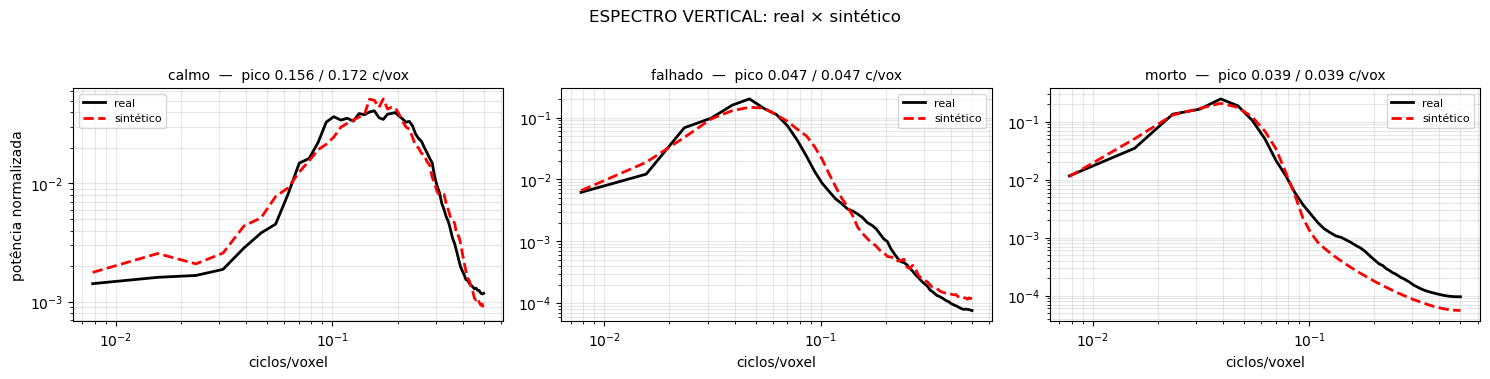


score médio das 3 regiões: 0.640


In [7]:
# FEATURES DAS SEÇÕES SINTÉTICAS PÓS-FORMAT (TILES 3D DE VERDADE, COM FALHAS)
def synthFeatures(name):
    reg = REGION[name]
    return np.array([features(reg.format(np.clip(sec*reg.gain*j, -CLIP, CLIP)))
                     for (sec, _, _), j in zip(PILOT[name], JIT[name])])


# DISTÂNCIA ATÉ O ALVO PELOS QUANTIS p10/p50/p90, EM DESVIOS ROBUSTOS DO PRÓPRIO BLOCO
def score(name, F):
    t, q = TARGET[name], np.percentile(F, [10, 50, 90], axis=0)
    sdf = sdFloor(t['med'], t['sd'])
    d   = [(q[1] - t['q'][2])/sdf, (q[0] - t['q'][0])/sdf, (q[2] - t['q'][4])/sdf]
    s = float(np.mean((np.minimum(d[0]**2, 25) + 0.5*np.minimum(d[1]**2, 25)
                       + 0.5*np.minimum(d[2]**2, 25))/2))
    return s, d[0], q[1]


# TRÊS MEDIDAS INDEPENDENTES: AS 40 FEATURES, O ESPECTRO VERTICAL E A GEOMETRIA DAS FALHAS
def validate(show=8):
    fig, axes = plt.subplots(1, 3, figsize=(15, 3.6))
    report = {}

    for ax, name in zip(axes, REGIONS):
        reg, t = REGION[name], TARGET[name]
        F = synthFeatures(name)
        s, d, med = score(name, F)
        report[name] = s

        print(f'\n=== {name}   score={s:.3f}   |desvio| médio={np.abs(d).mean():.2f} σ   '
              f'máx={np.abs(d).max():.2f} σ ({FEATURES[int(np.argmax(np.abs(d)))]})')
        print(f'    {"feature":8s} {"real":>9s} {"synth":>9s} {"desvio":>8s}')

        for i in np.argsort(-np.abs(d))[:show]:
            print(f'    {FEATURES[i]:8s} {t["q"][2][i]: 9.4f} {med[i]: 9.4f} {d[i]: 8.2f}')

        secs = [reg.format(np.clip(sec*reg.gain*j, -CLIP, CLIP))
                for (sec, _, _), j in zip(PILOT[name], JIT[name])]
        vs = float(np.nanmedian([visibility(s, m) for s, (_, m, _) in zip(secs, PILOT[name])]))
        fs, fr = faultStats([m for _, m, _ in PILOT[name]]), t['faults']

        print(f'    falha: fração {fr["fracMean"]:.4f}/{fs["fracMean"]:.4f}   '
              f'seções vazias {fr["zero"]:.2f}/{fs["zero"]:.2f}   '
              f'traços {fr["tracePerCrop"]:.2f}/{fs["tracePerCrop"]:.2f}   '
              f'dip {np.round(np.array(fr["dip"])[[0, 2, 4]], 0)}/'
              f'{np.round(np.array(fs["dip"])[[0, 2, 4]], 0)}   (real/synth)')
        print(f'    visibilidade do rótulo: real={t["visib"]:.2f}  sintético={vs:.2f}'
              f'   (≈1 = máscara sobre imagem lisa, o pior caso)')

        spec = lambda a: (np.abs(np.fft.rfft(a - a.mean(0, keepdims=True), axis=0))**2).mean(1)
        Pr = np.mean([spec(c) for c, _ in realCrops(*REGIONS[name]['zband'])], 0)
        Ps = np.mean([spec(s) for s in secs], 0)
        ax.loglog(FREQZ[1:], Pr[1:]/Pr[1:].sum(), 'k-',  lw=2, label='real')
        ax.loglog(FREQZ[1:], Ps[1:]/Ps[1:].sum(), 'r--', lw=2, label='sintético')
        pkr, pks = FREQZ[1 + np.argmax(Pr[1:])], FREQZ[1 + np.argmax(Ps[1:])]
        ax.set_title(f'{name}  —  pico {pkr:.3f} / {pks:.3f} c/vox', fontsize=10)
        ax.set_xlabel('ciclos/voxel')
        ax.grid(alpha=.3, which='both')
        ax.legend(fontsize=8)

    axes[0].set_ylabel('potência normalizada')
    fig.suptitle('ESPECTRO VERTICAL: real × sintético', y=1.04)
    plt.tight_layout()
    plt.show()
    print(f'\nscore médio das 3 regiões: {np.mean(list(report.values())):.3f}')
    return report


REPORT = validate()

## 6. Comparação visual com o bloco real

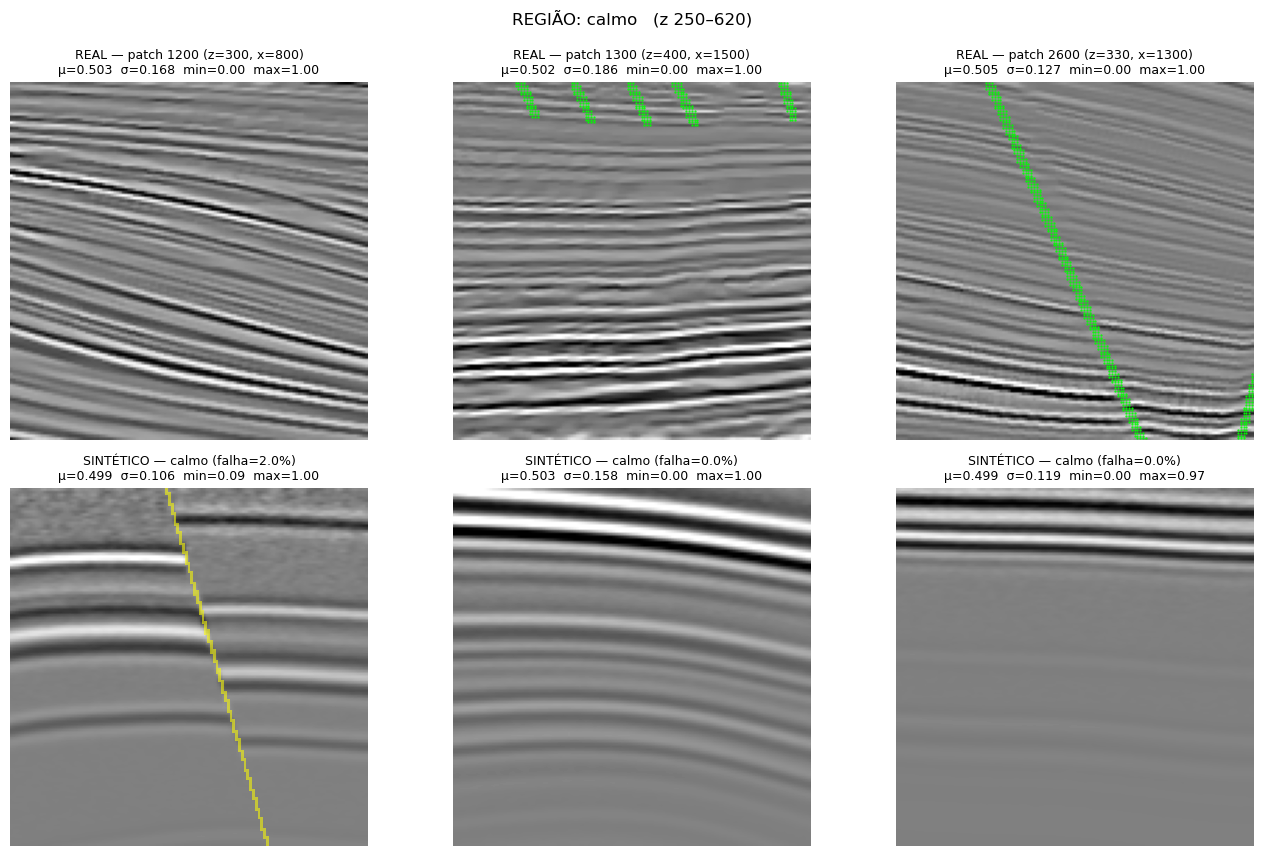

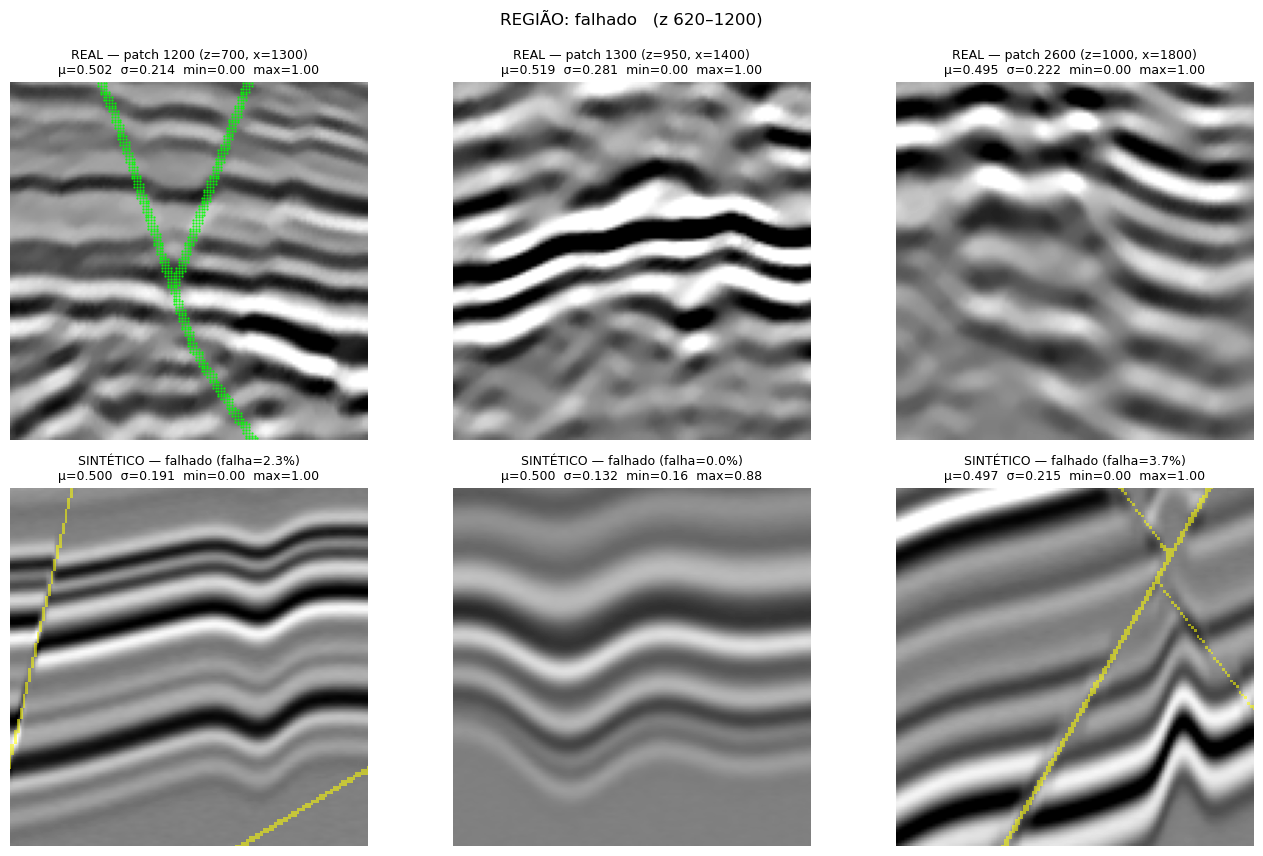

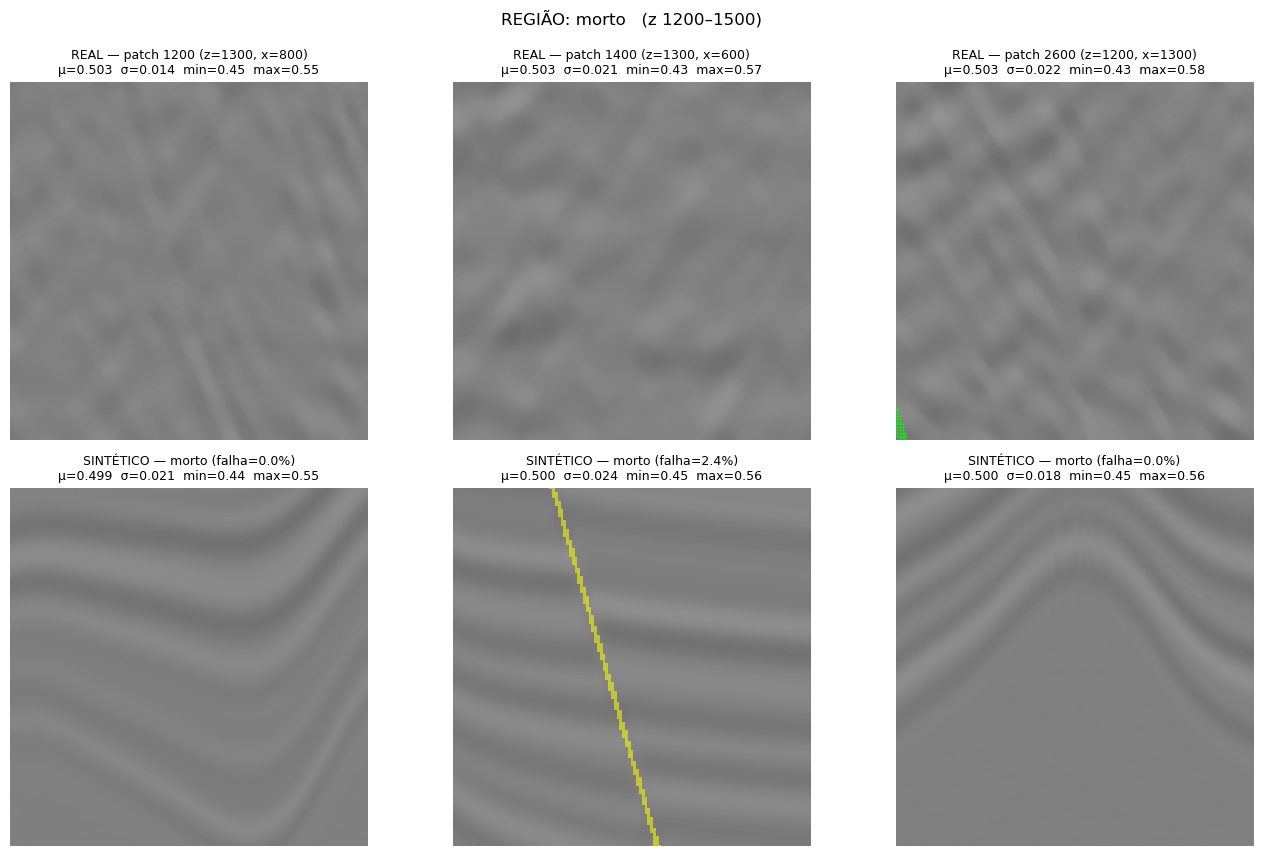

In [8]:
# EM CIMA OS RECORTES REAIS COM A ANOTAÇÃO (VERDE), EMBAIXO AS SEÇÕES SINTÉTICAS PÓS-FORMAT COM A MÁSCARA (VERMELHO)
def compareRegion(name, seed0=42):
    cfg, reg = REGIONS[name], REGION[name]
    rng = np.random.RandomState(seed0)
    stats = lambda a: f'μ={a.mean():.3f}  σ={a.std():.3f}  min={a.min():.2f}  max={a.max():.2f}'
    fig, axes = plt.subplots(2, 3, figsize=(13.5, 8.6))

    for j, (pid, z0, x0) in enumerate(cfg['reals']):
        crop = SECTIONS[pid][z0:z0+128, x0:x0+128]
        gy, gx = np.where(INTERPRETADO[pid][z0:z0+128, x0:x0+128])
        axes[0, j].imshow(crop, cmap='gray', vmin=0, vmax=1)
        axes[0, j].scatter(gx, gy, s=0.4, c='lime', alpha=0.9)
        axes[0, j].set_title(f'REAL — patch {pid} (z={z0}, x={x0})\n{stats(crop)}', fontsize=9)

    for j in range(3):
        sec, m = reg.section(seed=int(rng.randint(0, 1e6)))
        axes[1, j].imshow(sec, cmap='gray', vmin=0, vmax=1)
        if m.any():
            axes[1, j].imshow(np.ma.masked_where(m == 0, m), cmap='autumn', alpha=0.55, vmin=0, vmax=1)
        axes[1, j].set_title(f'SINTÉTICO — {name} (falha={m.mean()*100:.1f}%)\n{stats(sec)}', fontsize=9)

    for ax in axes.ravel():
        ax.axis('off')

    fig.suptitle(f'REGIÃO: {name}   (z {cfg["zband"][0]}–{cfg["zband"][1]})', fontsize=12, y=0.99)
    plt.tight_layout()
    plt.show()


for i, name in enumerate(REGIONS):
    compareRegion(name, seed0=100*i + 42)

## 7. O que a classe global não alcança
Dois limites são estruturais da `SyntheticGenerator` e não dá para corrigir sem mexer nela,
o que este notebook não faz:

* **coerência da zona morta.** O pipeline monta refletividade 1D e convolve em z, então o
  campo é sempre *localmente planar*. Varrendo `foldSigma` de 3 a 30 e `foldAmplitude` até
  ±80, a coerência nunca desce de ≈0.90 — o real na banda morta é 0.65. A única fonte de
  incoerência da classe é o `applyNoise`, de `sigma=(1,1,0.5)` fixo, que injeta alta
  frequência vertical que a zona morta real não tem. **Falhamento denso foi medido em 3D e
  não resolve**: 8–18 e 20–34 falhas por tile *pioraram* a textura (1.31–1.35 contra 1.22
  com falhamento esparso). O resíduo aparece em `cohw`/`coh25/50/75`;

* **mergulho aparente raso demais.** Em `applyFaulting` o azimute é `uniform(0, 2π)`, logo
  o mergulho visto na seção é `atan(tan δ · |sin φ|)`: mesmo com δ alto, ~13% das falhas
  cruzam a seção quase deitadas. O especialista não anota traço abaixo de ~39°, então o p5
  do mergulho sintético fica sempre abaixo do real. Não há parâmetro de azimute para mexer.

Um terceiro detalhe, menor: o traço de falha sai mais comprido que o do especialista —
metade dos rejeitos usa a rampa linear do `computeThrowMap`, que quase não decai dentro do
tile e por isso rotula o plano inteiro. Como a fração de máscara é o que mais importa para
o treino, ela foi casada pelo `faultZoneWidth`, a única variável que mexe só no rótulo.

## 8. Geração do dataset
220 tiles por região → **660** em `../Dataset/dataset_marlim_opt_2/original`, crus em
[−clip, +clip] e no eixo (x, z, y) como os outros datasets. O `synthetic.json` guarda as
opções de cada região, os números da camada de Marlim, a semente e a regra de semente —
regerar a partir dele reproduz os tiles bit a bit.

In [ ]:
# UM TILE DO DATASET, SALVO EM (x, z, y) E CRU EM [−clip, +clip]
def datasetWorker(args):
    name, i, seed, imgDir, mskDir = args
    img, msk = REGION[name].get(seed=seed)
    np.save(f'{imgDir}/{name}_{i:03d}.npy', np.transpose(img, (0, 2, 1)))
    np.save(f'{mskDir}/{name}_{i:03d}.npy', np.transpose(msk, (0, 2, 1)))


def buildDataset(n=PER_REGION, outDir=f'{OUT_DIR}/original', seed0=SEED0):
    imgDir, mskDir = f'{outDir}/images', f'{outDir}/masks'

    for d in (imgDir, mskDir):
        shutil.rmtree(d, ignore_errors=True)
        os.makedirs(d)

    tasks = [(name, i, seed0 + 1000*k + i, imgDir, mskDir)
             for k, name in enumerate(REGIONS) for i in range(n)]

    with ProcessPoolExecutor(NJOBS, mp_context=mp.get_context('fork')) as ex:
        list(tqdm(ex.map(datasetWorker, tasks), total=len(tasks), desc=DATASET))
    return imgDir


# CONFERE O QUE O FORMAT.IPYNB VAI ENCONTRAR: p01/p99 DO CONJUNTO E σ POR REGIÃO, EM DUAS PASSADAS
def datasetReport(imgDir):
    files = sorted(Path(imgDir).glob('*.npy'))
    pool  = np.concatenate([np.load(f).ravel()[::37] for f in tqdm(files, desc='p01/p99')])
    p01, p99 = np.percentile(pool, [1, 99])
    del pool
    print(f'\n{len(files)} tiles   p01={p01:.4f}  p99={p99:.4f}   (clip = ±{CLIP})')

    per = {n: [] for n in REGIONS}
    for f in tqdm(files, desc='σ pós-Format'):
        a = np.clip((np.clip(np.load(f), p01, p99) - p01)/(p99 - p01), 0, 1)
        per[f.stem.rsplit('_', 1)[0]].append((a.std(), a.mean(), a.min(), a.max()))

    for n, v in per.items():
        v = np.array(v)
        print(f'  {n:9s} {len(v):4d} tiles   σ={np.median(v[:, 0]):.4f} '
              f'(alvo {np.exp(TARGET[n]["q"][2, 0]):.4f})   μ={v[:, 1].mean():.3f}   '
              f'min={v[:, 2].min():.3f}  max={v[:, 3].max():.3f}')
    return float(p01), float(p99)


if GENERATE:
    imgDir   = buildDataset()
    D01, D99 = datasetReport(imgDir)

    meta = dict(
        dataset=DATASET,
        generator='Synthetic/index.py :: SyntheticGenerator (classe global, não modificada)',
        notebook='Marlim/Generator2.ipynb',
        shape=list(SHAPE), clipLevel=CLIP,
        perRegion=PER_REGION, total=PER_REGION*len(REGIONS), seed0=SEED0,
        seedRule='np.random.seed(seed0 + 1000*indice_da_regiao + indice_do_tile), regiões na ordem em que aparecem em "regions"',
        datasetPercentiles=dict(p01=D01, p99=D99),
        regions={n: dict(REGION[n].asdict(), score=REPORT[n], faults=faultStats([m for _, m, _ in PILOT[n]])) for n in REGIONS},
    )

    json.dump(meta, open(f'{OUT_DIR}/synthetic.json', 'w'), ensure_ascii=False, indent=4)

    if not os.path.exists(f'{OUT_DIR}/Format.ipynb'):     # Format genérico do projeto
        shutil.copy('../Dataset/marlim_opt/Format.ipynb', f'{OUT_DIR}/Format.ipynb')

    print(f'\nOK: {meta["total"]} tiles em {OUT_DIR}')
    print('agora rode o Format.ipynb do dataset (p01/p99 global → [0,1]) e confira o DataBase.csv')

p01/p99: 100%|██████████| 660/660 [00:01<00:00, 485.86it/s]



660 tiles   p01=-0.4500  p99=0.4500   (clip = ±0.45)


σ pós-Format: 100%|██████████| 660/660 [00:06<00:00, 96.91it/s]


  calmo      220 tiles   σ=0.1693 (alvo 0.1666)   μ=0.500   min=0.000  max=1.000
  falhado    220 tiles   σ=0.1592 (alvo 0.1591)   μ=0.500   min=0.000  max=1.000
  morto      220 tiles   σ=0.0202 (alvo 0.0205)   μ=0.500   min=0.341  max=0.668

OK: 660 tiles em ../Dataset/dataset_marlim_opt_2
agora rode o Format.ipynb do dataset (p01/p99 global → [0,1]) e confira o DataBase.csv
